# PPO Discrete Baseline Runner

This notebook launches fresh `PPO Discrete` baselines on `matlab_env_python_replica` using the **exact same teleoperation formulation** as the DQN notebook:

- `30 s` episode duration
- `10 s` skin-to-fat switch
- midpoint reset
- force input `5 N` amplitude, `15 N` bias, `6 rad/s`
- stroke limit handled with mechanical clamp mode
- state variant `S0_baseline_full10`
- reward variant `eqgrad_t40_tr40_nojerk`
- both FE modes: `switched_dynamics` and `gui_skin_locked`


## Baseline Config


In [1]:
import subprocess
import sys
from pathlib import Path

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    for root in (candidate, candidate / 'TeleopWithRL'):
        if (root / 'matlab_env_python_replica').exists() and (root / 'notebooks' / '_teleop_nb.py').exists():
            for path_to_add in (root.parent, root):
                if str(path_to_add) not in sys.path:
                    sys.path.insert(0, str(path_to_add))
            break
    else:
        continue
    break
else:
    raise RuntimeError('Could not find TeleopWithRL notebook root.')

from notebooks._teleop_nb import load_json, project_python_executable, repo_paths, show_image, show_rows
from TeleopWithRL.matlab_env_python_replica.policy_gradient_experiments.paths import suite_root as policy_gradient_suite_root

P = repo_paths()
REPO = P['repo']
WORKSPACE = REPO.parent
PYTHON = project_python_executable(REPO)
PG_RESULTS = REPO / 'matlab_env_python_replica' / 'policy_gradient_experiments' / 'results'

ALGO_KEY = 'ppo_discrete'
ALGO_LABEL = 'PPO Discrete'
ALGO_TAG = 'ppod'
RUN_DIR = 'ppod'

CFG = {
    'study_name': f'{ALGO_TAG}_eqg40_b01',
    'env_mode': 'changing_skin_fat',
    'episode_duration_s': 30.0,
    'env_switch_time_s': 10.0,
    'reset_position_mode': 'midpoint',
    'stroke_limit_mode': 'clamp',
    'force_amp_N': 5.0,
    'force_bias_N': 15.0,
    'force_freq_rad_s': 6.0,
    'force_phase_rad': 0.0,
    'force_waveform': 'sine',
    'reward_variant': 'eqgrad_t40_tr40_nojerk',
    'state_variant': 'S0_baseline_full10',
    'train_episodes': 2500,
    'parallel_envs': 8,
    'eval_every_episodes': 100,
    'test_episodes': 100,
    'seed': 42,
    'parallel_workers': 1,
    'worker_torch_threads': 1,
    'skip_existing': True,
}

MODE_LABELS = {
    'dyn': 'switched_dynamics',
    'gui': 'gui_skin_locked',
}

RUN_ROOTS = {
    mode: policy_gradient_suite_root(MODE_LABELS[mode], f"{CFG['study_name']}_{mode}") / '00b' / RUN_DIR
    for mode in MODE_LABELS
}

CMD = [
    str(PYTHON),
    '-m',
    'TeleopWithRL.matlab_env_python_replica.policy_gradient_experiments.run_policy_gradient_baselines_both_fe',
    '--algo', ALGO_KEY,
    '--study-name', CFG['study_name'],
    '--env-mode', CFG['env_mode'],
    '--episode-duration', str(CFG['episode_duration_s']),
    '--env-switch-time', str(CFG['env_switch_time_s']),
    '--reset-position-mode', CFG['reset_position_mode'],
    '--stroke-limit-mode', CFG['stroke_limit_mode'],
    '--force-amp', str(CFG['force_amp_N']),
    '--force-bias', str(CFG['force_bias_N']),
    '--force-freq-rad', str(CFG['force_freq_rad_s']),
    '--force-phase', str(CFG['force_phase_rad']),
    '--force-waveform', CFG['force_waveform'],
    '--reward-variant', CFG['reward_variant'],
    '--state-variant', CFG['state_variant'],
    '--train-episodes', str(CFG['train_episodes']),
    '--parallel-envs', str(CFG['parallel_envs']),
    '--eval-every-episodes', str(CFG['eval_every_episodes']),
    '--test-episodes', str(CFG['test_episodes']),
    '--seed', str(CFG['seed']),
    '--parallel-workers', str(CFG['parallel_workers']),
    '--worker-torch-threads', str(CFG['worker_torch_threads']),
]
if CFG['skip_existing']:
    CMD.append('--skip-existing')

show_rows(
    [{
        'algo': ALGO_LABEL,
        'reward_variant': CFG['reward_variant'],
        'state_variant': CFG['state_variant'],
        'episode_duration_s': CFG['episode_duration_s'],
        'env_switch_time_s': CFG['env_switch_time_s'],
        'stroke_limit_mode': CFG['stroke_limit_mode'],
        'force_amp_N': CFG['force_amp_N'],
        'force_bias_N': CFG['force_bias_N'],
        'force_freq_rad_s': CFG['force_freq_rad_s'],
        'train_episodes': CFG['train_episodes'],
        'parallel_envs': CFG['parallel_envs'],
        'test_episodes': CFG['test_episodes'],
        'python_executable': str(PYTHON),
        'dyn_run_root': str(RUN_ROOTS['dyn']),
        'gui_run_root': str(RUN_ROOTS['gui']),
        'command': subprocess.list2cmdline(CMD),
    }],
    title=f'{ALGO_LABEL} baseline run config',
    max_rows=10,
)


### PPO Discrete baseline run config

algo,reward_variant,state_variant,episode_duration_s,env_switch_time_s,stroke_limit_mode,force_amp_N,force_bias_N,force_freq_rad_s,train_episodes,parallel_envs,test_episodes,python_executable,dyn_run_root,gui_run_root,command
PPO Discrete,eqgrad_t40_tr40_nojerk,S0_baseline_full10,30.0,10.0,clamp,5.0,15.0,6.0,2500,8,100,C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\.venv\Scripts\python.exe,C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\TeleopWithRL\matlab_env_python_replica\policy_gradient_experiments\results\dyn\ppod_eqg40_b01_dyn\00b\ppod,C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\TeleopWithRL\matlab_env_python_replica\policy_gradient_experiments\results\gui\ppod_eqg40_b01_gui\00b\ppod,"""C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\.venv\Scripts\python.exe"" -m TeleopWithRL.matlab_env_python_replica.policy_gradient_experiments.run_policy_gradient_baselines_both_fe --algo ppo_discrete --study-name ppod_eqg40_b01 --env-mode changing_skin_fat --episode-duration 30.0 --env-switch-time 10.0 --reset-position-mode midpoint --stroke-limit-mode clamp --force-amp 5.0 --force-bias 15.0 --force-freq-rad 6.0 --force-phase 0.0 --force-waveform sine --reward-variant eqgrad_t40_tr40_nojerk --state-variant S0_baseline_full10 --train-episodes 2500 --parallel-envs 8 --eval-every-episodes 100 --test-episodes 100 --seed 42 --parallel-workers 1 --worker-torch-threads 1 --skip-existing"


In [2]:
print(subprocess.list2cmdline(CMD))
completed = subprocess.run(CMD, cwd=str(WORKSPACE), check=True)
print(f'Completed with return code {completed.returncode}.')


"C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\.venv\Scripts\python.exe" -m TeleopWithRL.matlab_env_python_replica.policy_gradient_experiments.run_policy_gradient_baselines_both_fe --algo ppo_discrete --study-name ppod_eqg40_b01 --env-mode changing_skin_fat --episode-duration 30.0 --env-switch-time 10.0 --reset-position-mode midpoint --stroke-limit-mode clamp --force-amp 5.0 --force-bias 15.0 --force-freq-rad 6.0 --force-phase 0.0 --force-waveform sine --reward-variant eqgrad_t40_tr40_nojerk --state-variant S0_baseline_full10 --train-episodes 2500 --parallel-envs 8 --eval-every-episodes 100 --test-episodes 100 --seed 42 --parallel-workers 1 --worker-torch-threads 1 --skip-existing
Completed with return code 0.


## Numeric Summary


In [3]:
summary_rows = []
metric_rows = []
artifact_rows = []
for mode, run_root in RUN_ROOTS.items():
    summary_path = run_root / 'l' / 'summary.json'
    plots_dir = run_root / 'p'
    artifact_rows.append({'fe_mode': MODE_LABELS[mode], 'summary_json': str(summary_path), 'plots_dir': str(plots_dir)})
    if not summary_path.exists():
        summary_rows.append({'fe_mode': MODE_LABELS[mode], 'status': 'missing', 'run_root': str(run_root)})
        continue
    data = load_json(summary_path)
    reset_options = dict(data.get('reset_options', {}))
    summary_rows.append({
        'fe_mode': MODE_LABELS[mode],
        'algo': data.get('algo_display_name', data.get('algo')),
        'label': data.get('label'),
        'tracking_rmse_m': data.get('tracking_rmse_m'),
        'transparency_rmse_w': data.get('transparency_rmse_w'),
        'pre_switch_tracking_rmse_m': data.get('pre_switch_tracking_rmse_m'),
        'post_switch_tracking_rmse_m': data.get('post_switch_tracking_rmse_m'),
        'pre_switch_transparency_rmse_w': data.get('pre_switch_transparency_rmse_w'),
        'post_switch_transparency_rmse_w': data.get('post_switch_transparency_rmse_w'),
        'invalid_episode_rate': data.get('invalid_episode_rate'),
        'episode_duration': data.get('episode_duration'),
        'env_switch_time': data.get('env_switch_time'),
        'force_amp': reset_options.get('force_amp'),
        'force_bias': reset_options.get('force_bias'),
        'force_freq_rad': reset_options.get('force_freq_rad'),
        'reset_position_mode': reset_options.get('reset_position_mode'),
        'state_variant': data.get('state_variant'),
        'reward_variant': data.get('reward_variant'),
        'out_dir': data.get('out_dir'),
    })
    metric_rows.append({
        'fe_mode': MODE_LABELS[mode],
        'track_rmse_mm': round(1000.0 * float(data.get('tracking_rmse_m') or 0.0), 3),
        'transp_rmse_w': round(float(data.get('transparency_rmse_w') or 0.0), 3),
        'pre_track_rmse_mm': round(1000.0 * float(data.get('pre_switch_tracking_rmse_m') or 0.0), 3),
        'post_track_rmse_mm': round(1000.0 * float(data.get('post_switch_tracking_rmse_m') or 0.0), 3),
        'pre_transp_rmse_w': round(float(data.get('pre_switch_transparency_rmse_w') or 0.0), 3),
        'post_transp_rmse_w': round(float(data.get('post_switch_transparency_rmse_w') or 0.0), 3),
        'mean_reward': round(float(data.get('mean_reward') or 0.0), 3),
    })

show_rows(metric_rows, title=f'{ALGO_LABEL} rollout RMSE metrics', max_rows=10)
show_rows(summary_rows, title=f'{ALGO_LABEL} baseline summaries', max_rows=10)
show_rows(artifact_rows, title=f'{ALGO_LABEL} artifact locations', max_rows=10)


### PPO Discrete rollout RMSE metrics

fe_mode,track_rmse_mm,transp_rmse_w,pre_track_rmse_mm,post_track_rmse_mm,pre_transp_rmse_w,post_transp_rmse_w,mean_reward
switched_dynamics,8.328,2.31,13.473,3.645,3.639,1.176,-1022.715
gui_skin_locked,20.034,5.781,23.002,18.371,4.03,6.481,-6286.993


### PPO Discrete baseline summaries

fe_mode,algo,label,tracking_rmse_m,transparency_rmse_w,pre_switch_tracking_rmse_m,post_switch_tracking_rmse_m,pre_switch_transparency_rmse_w,post_switch_transparency_rmse_w,invalid_episode_rate,episode_duration,env_switch_time,force_amp,force_bias,force_freq_rad,reset_position_mode,state_variant,reward_variant,out_dir
switched_dynamics,PPO Discrete,PPO Discrete_baseline_eqgrad_t40_tr40_nojerk,0.008328461427978245,2.3098871066096693,0.013472721157691854,0.0036452430563027383,3.639023030322571,1.1756374272339887,0.0,30.0,10.0,5.0,15.0,6.0,midpoint,S0_baseline_full10,eqgrad_t40_tr40_nojerk,C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\TeleopWithRL\matlab_env_python_replica\policy_gradient_experiments\results\dyn\ppod_eqg40_b01_dyn\00b\ppod
gui_skin_locked,PPO Discrete,PPO Discrete_baseline_eqgrad_t40_tr40_nojerk,0.020033671673964283,5.780740428719354,0.023001904586270674,0.0183705795720317,4.029648367127097,6.48123498069624,0.0,30.0,10.0,5.0,15.0,6.0,midpoint,S0_baseline_full10,eqgrad_t40_tr40_nojerk,C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\TeleopWithRL\matlab_env_python_replica\policy_gradient_experiments\results\gui\ppod_eqg40_b01_gui\00b\ppod


### PPO Discrete artifact locations

fe_mode,summary_json,plots_dir
switched_dynamics,C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\TeleopWithRL\matlab_env_python_replica\policy_gradient_experiments\results\dyn\ppod_eqg40_b01_dyn\00b\ppod\l\summary.json,C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\TeleopWithRL\matlab_env_python_replica\policy_gradient_experiments\results\dyn\ppod_eqg40_b01_dyn\00b\ppod\p
gui_skin_locked,C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\TeleopWithRL\matlab_env_python_replica\policy_gradient_experiments\results\gui\ppod_eqg40_b01_gui\00b\ppod\l\summary.json,C:\Users\aha173\OneDrive - American University of Beirut\AGV research\spring VIPP obsidian notes\VIPP\VIPP naseem\VIPP\Teleop\TeleopWithRL\matlab_env_python_replica\policy_gradient_experiments\results\gui\ppod_eqg40_b01_gui\00b\ppod\p


## Plot Gallery


### switched_dynamics


### switched_dynamics: Training metrics

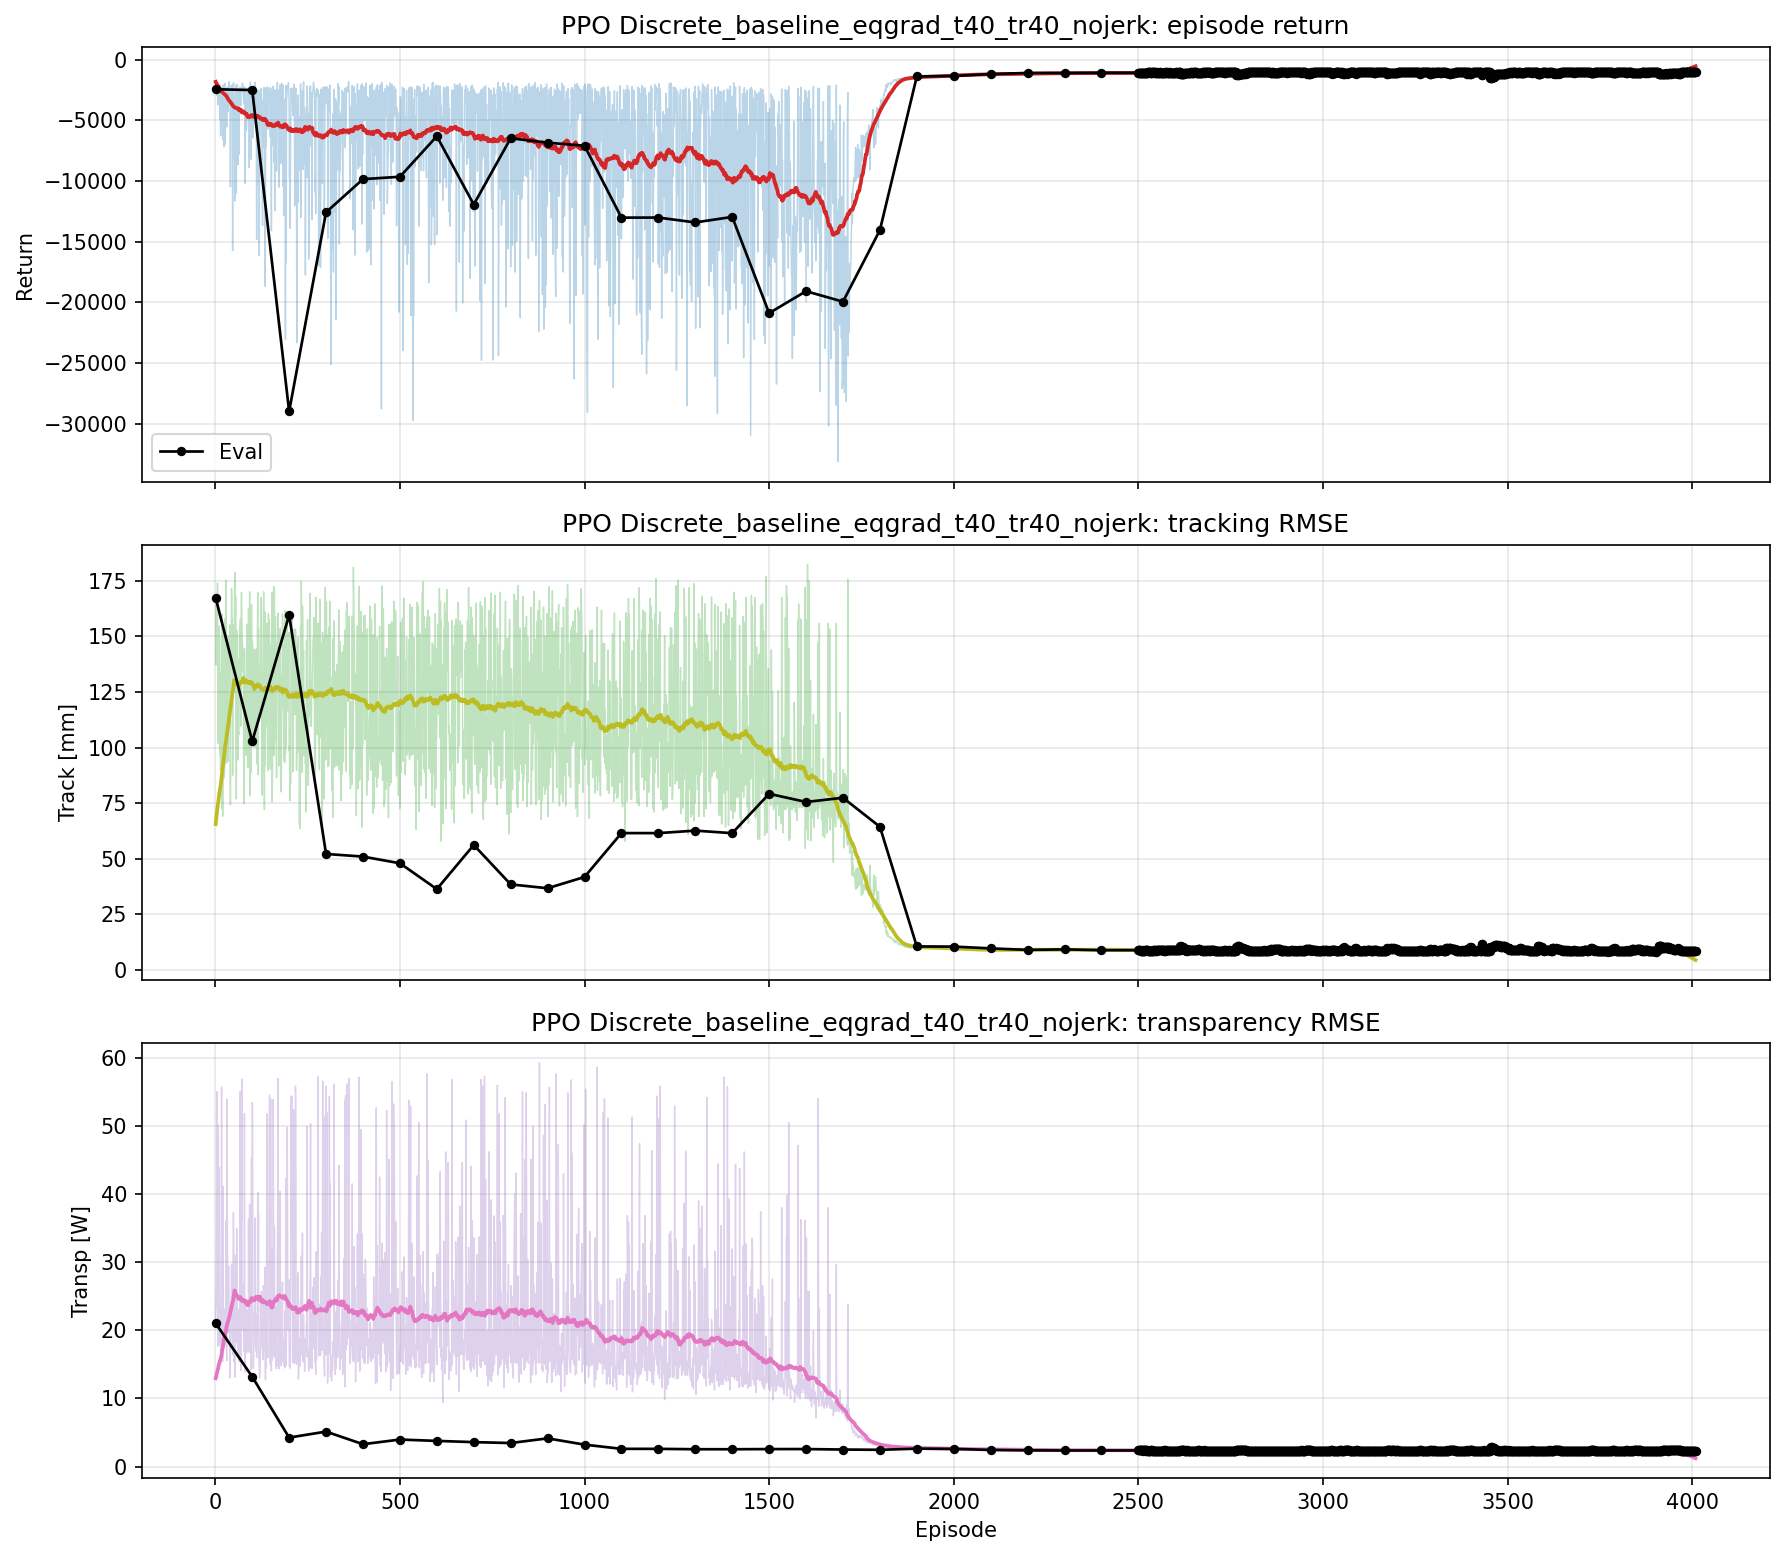

### switched_dynamics: Evaluation roll plot

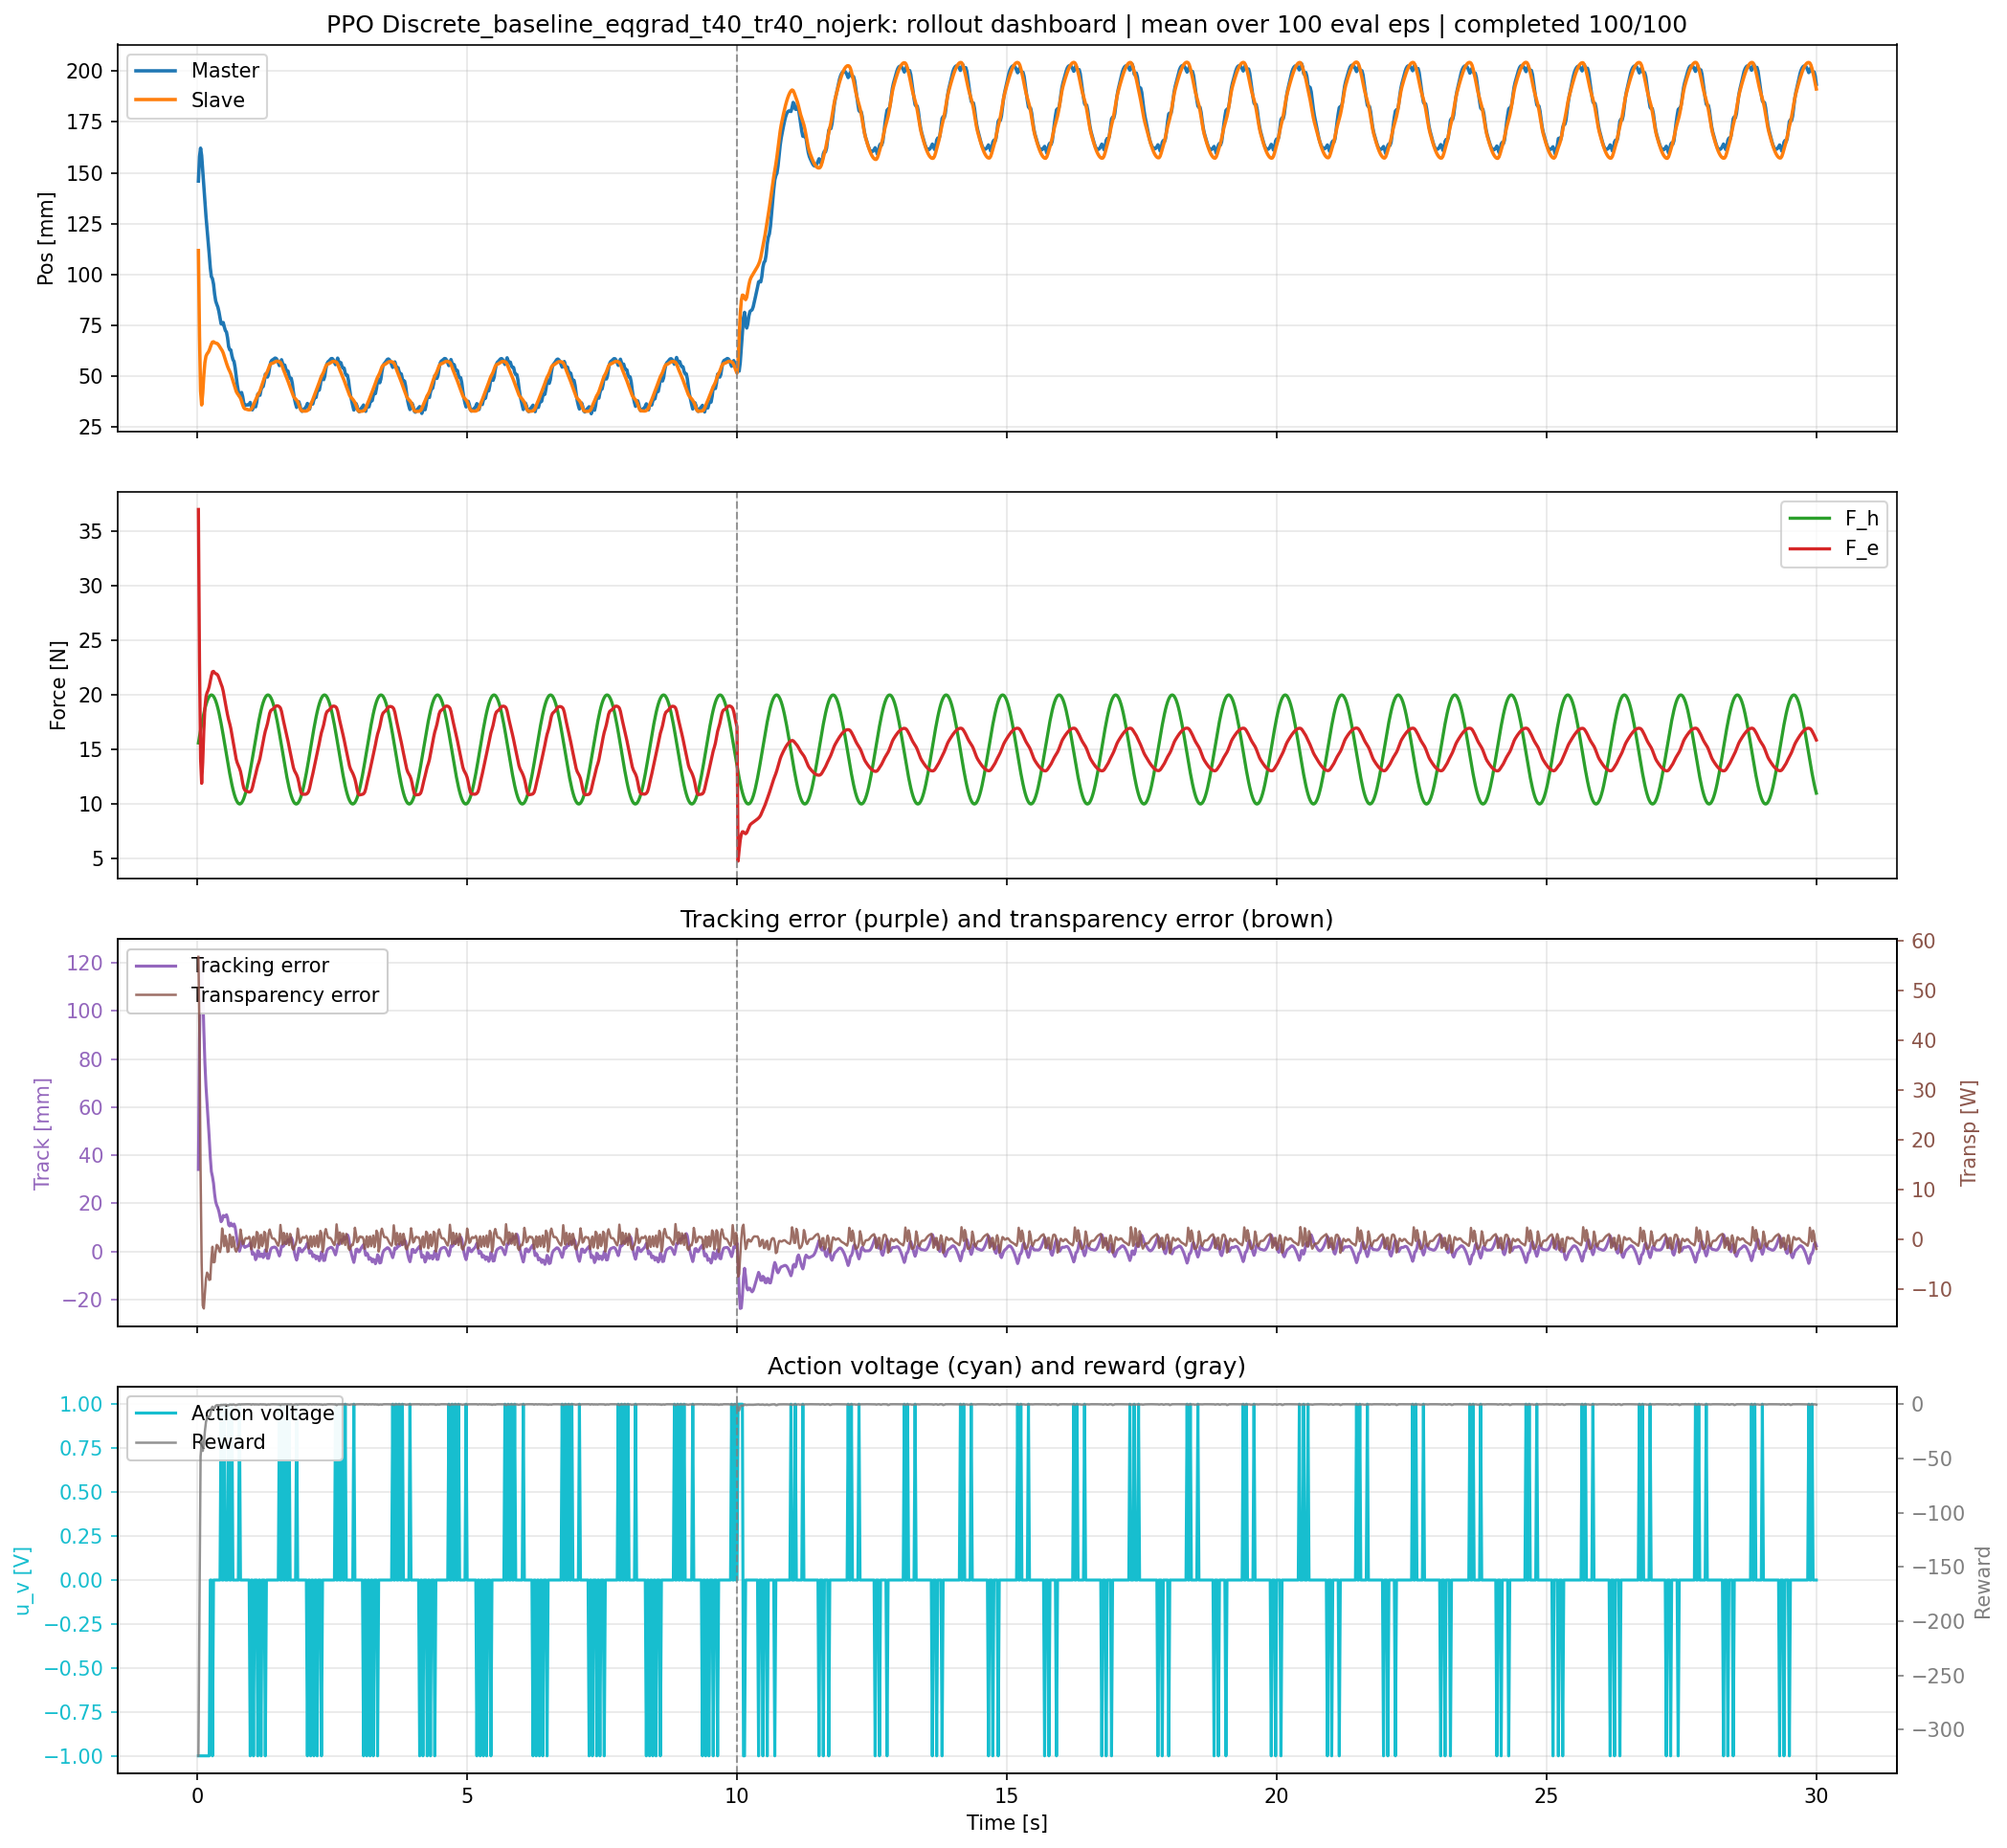

### switched_dynamics: Evaluation action plot

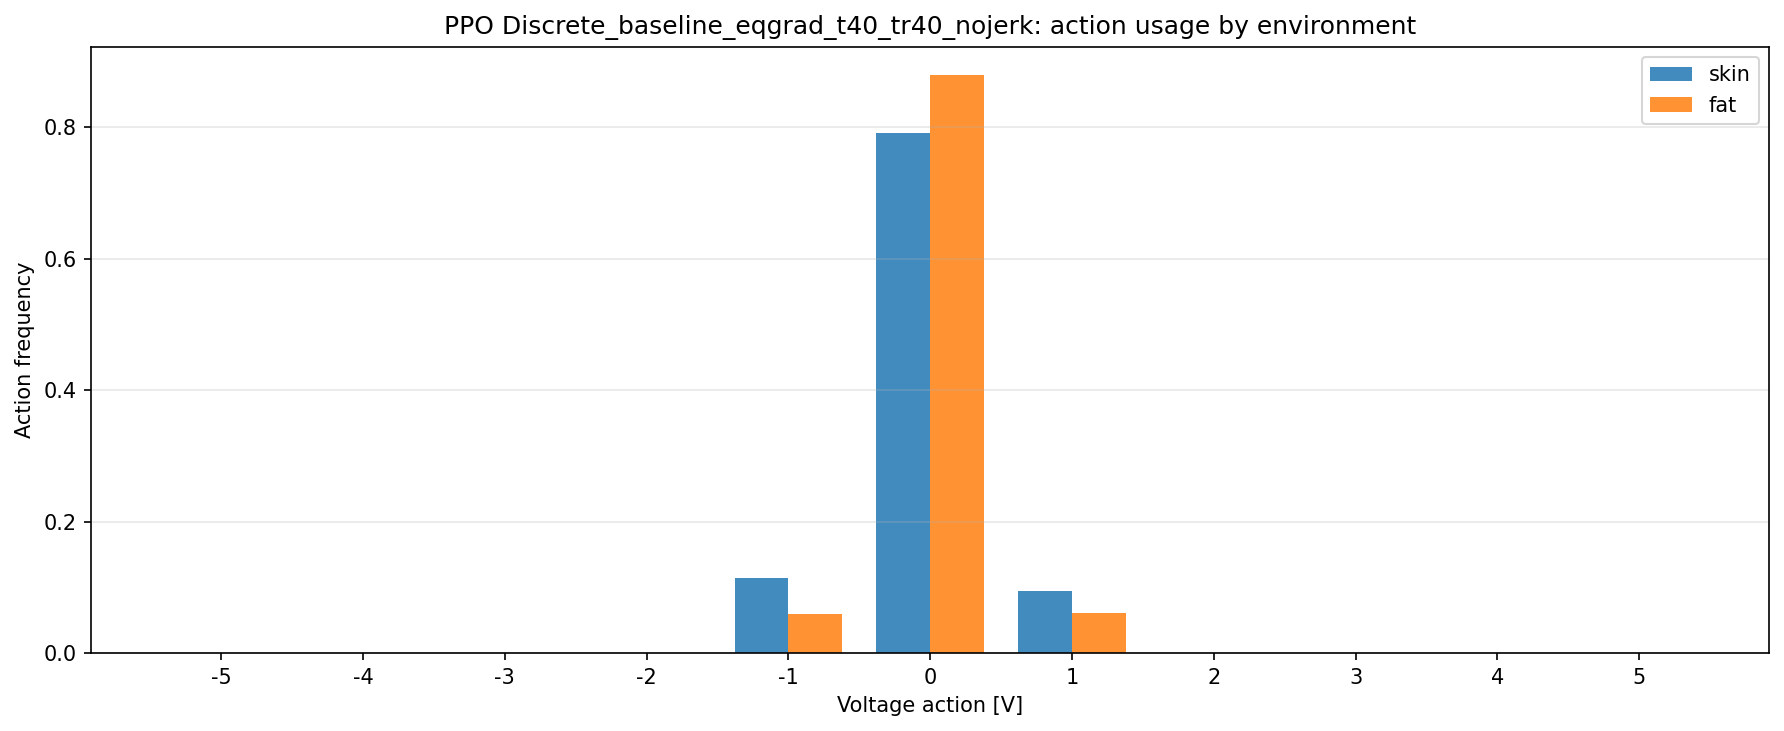

### switched_dynamics: Evaluation trajectory plot

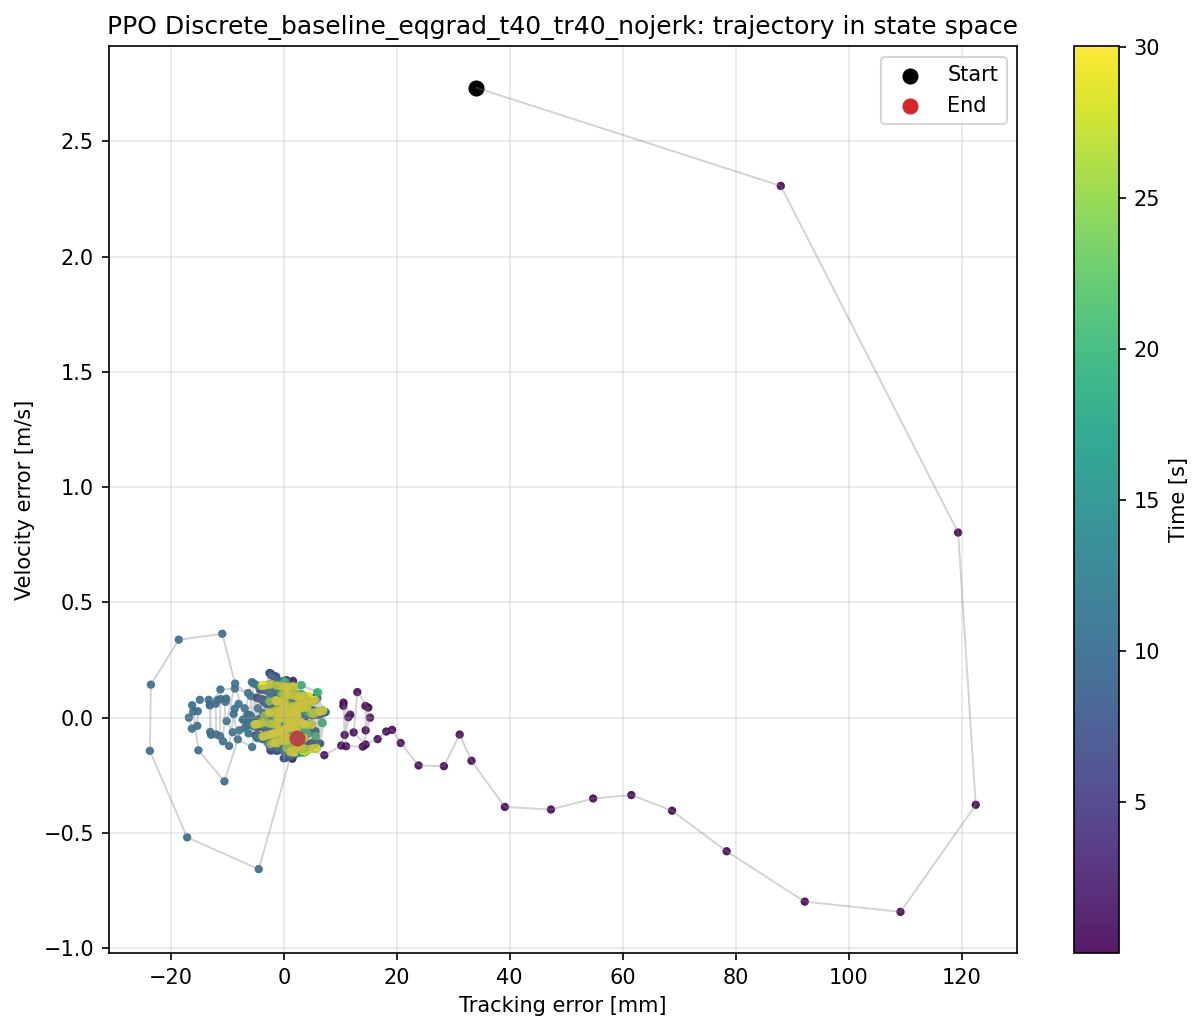

### switched_dynamics: Policy slices

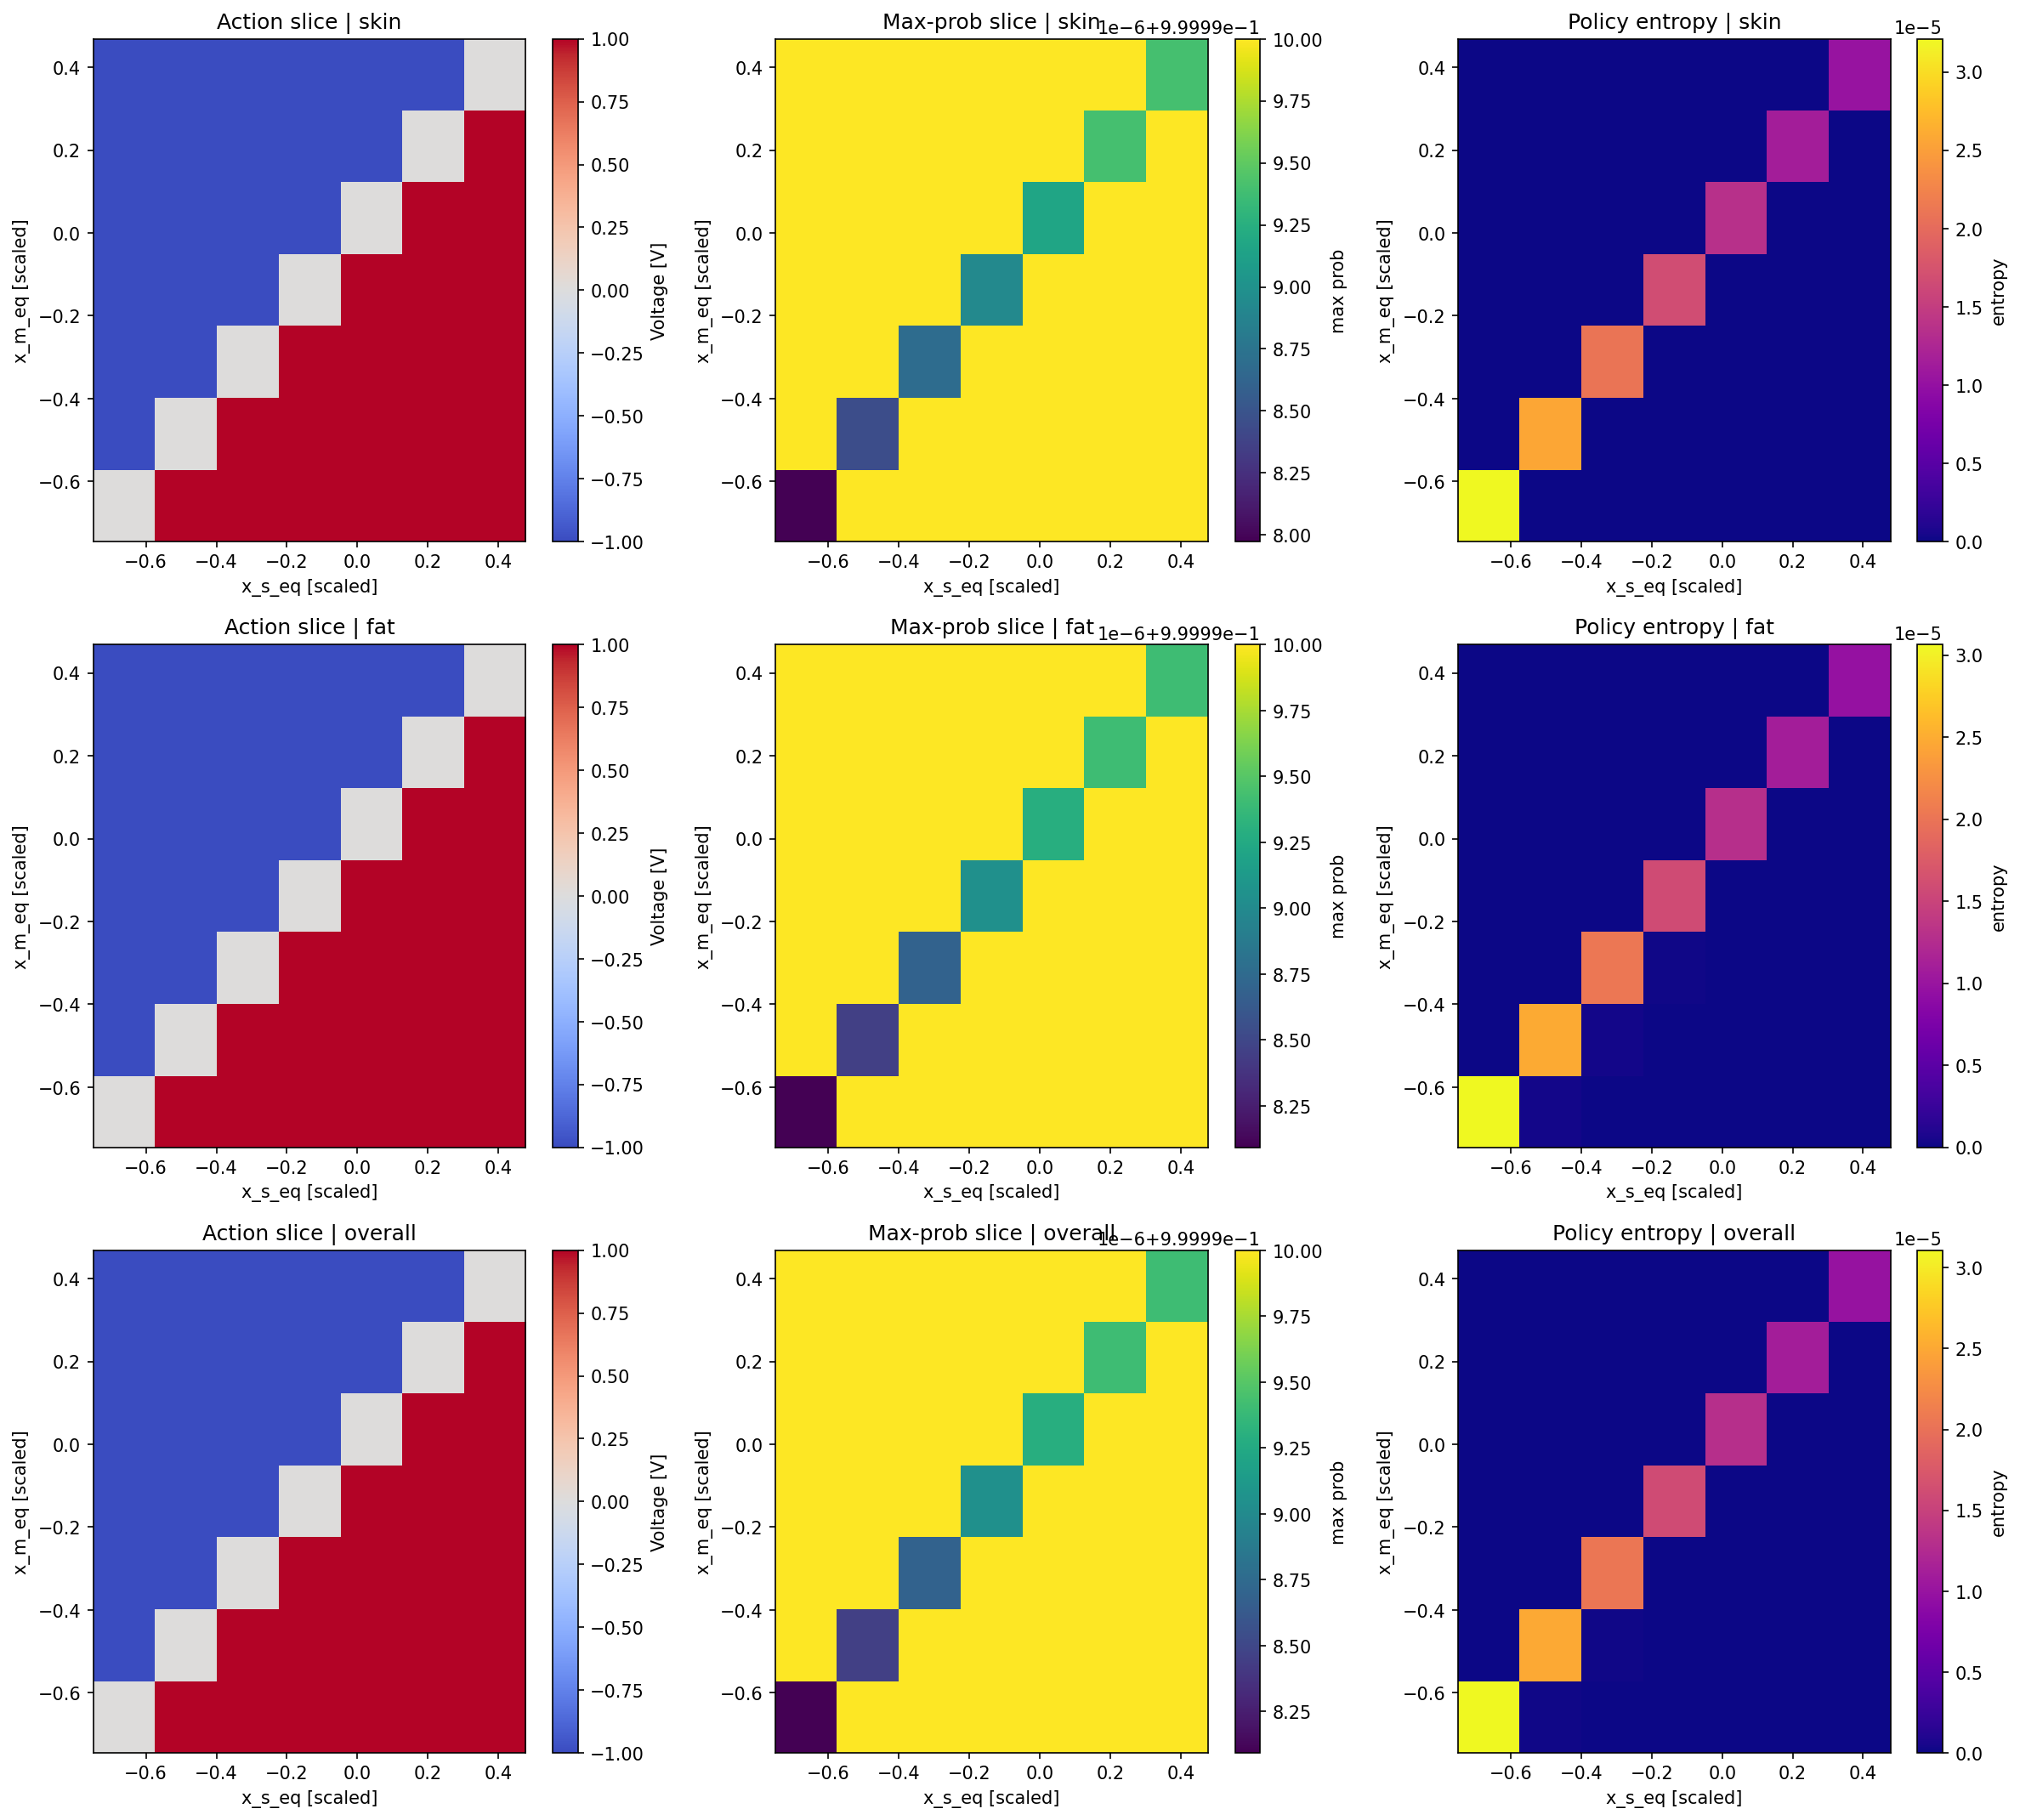

In [4]:
plot_specs = [
    ('train.png', 'Training metrics'),
    ('roll.png', 'Evaluation roll plot'),
    ('act.png', 'Evaluation action plot'),
    ('traj.png', 'Evaluation trajectory plot'),
    ('slices.png', 'Policy slices'),
]

run_root = RUN_ROOTS['dyn']
for filename, title in plot_specs:
    show_image(run_root / 'p' / filename, title=f"{MODE_LABELS['dyn']}: {title}")


### gui_skin_locked


### gui_skin_locked: Training metrics

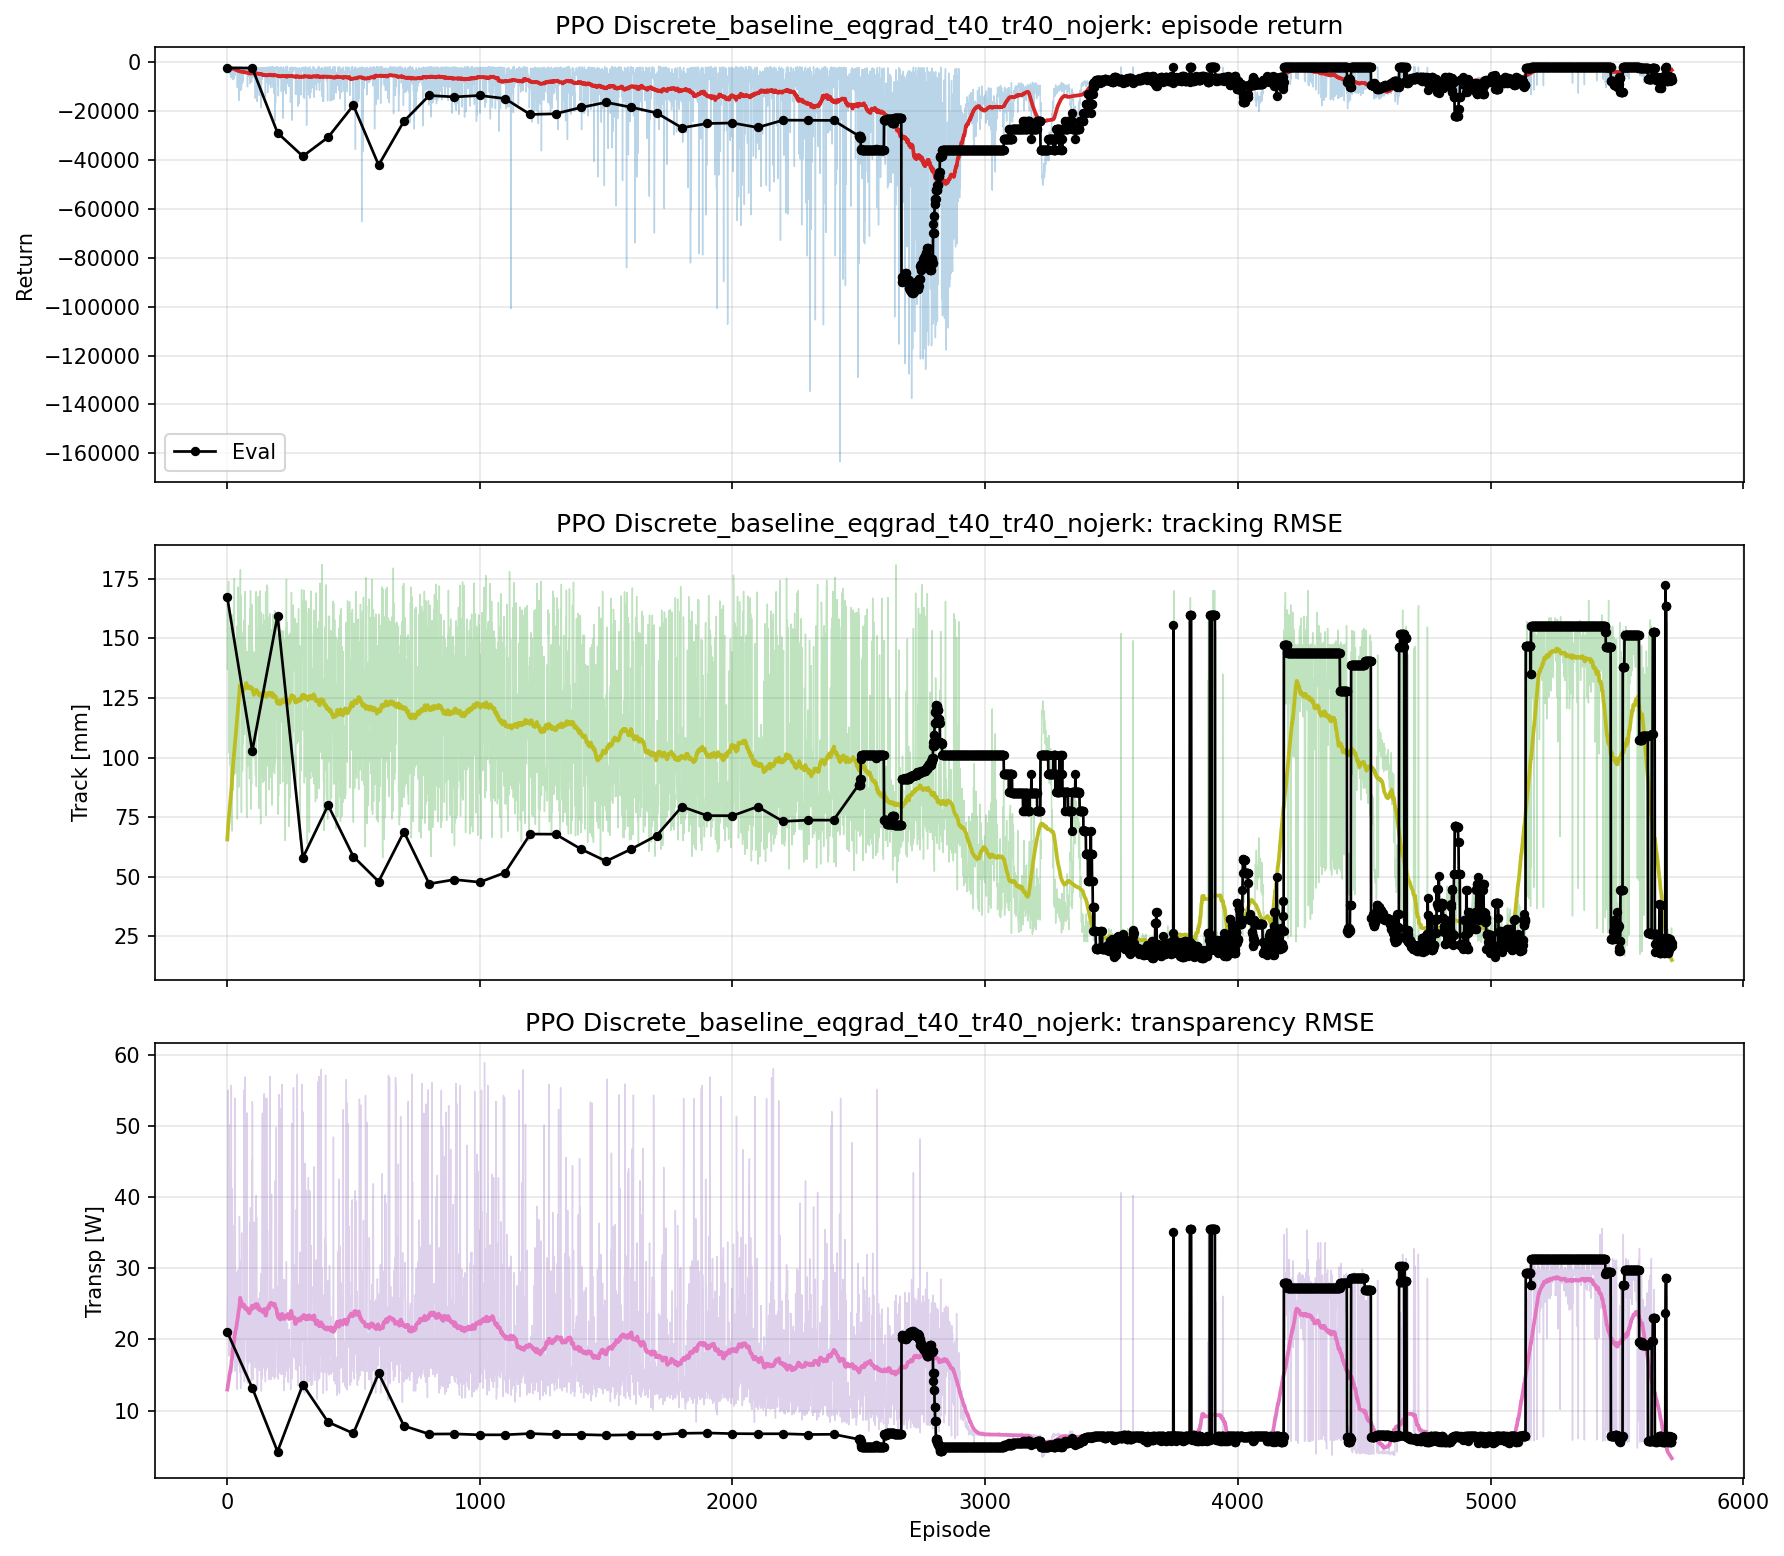

### gui_skin_locked: Evaluation roll plot

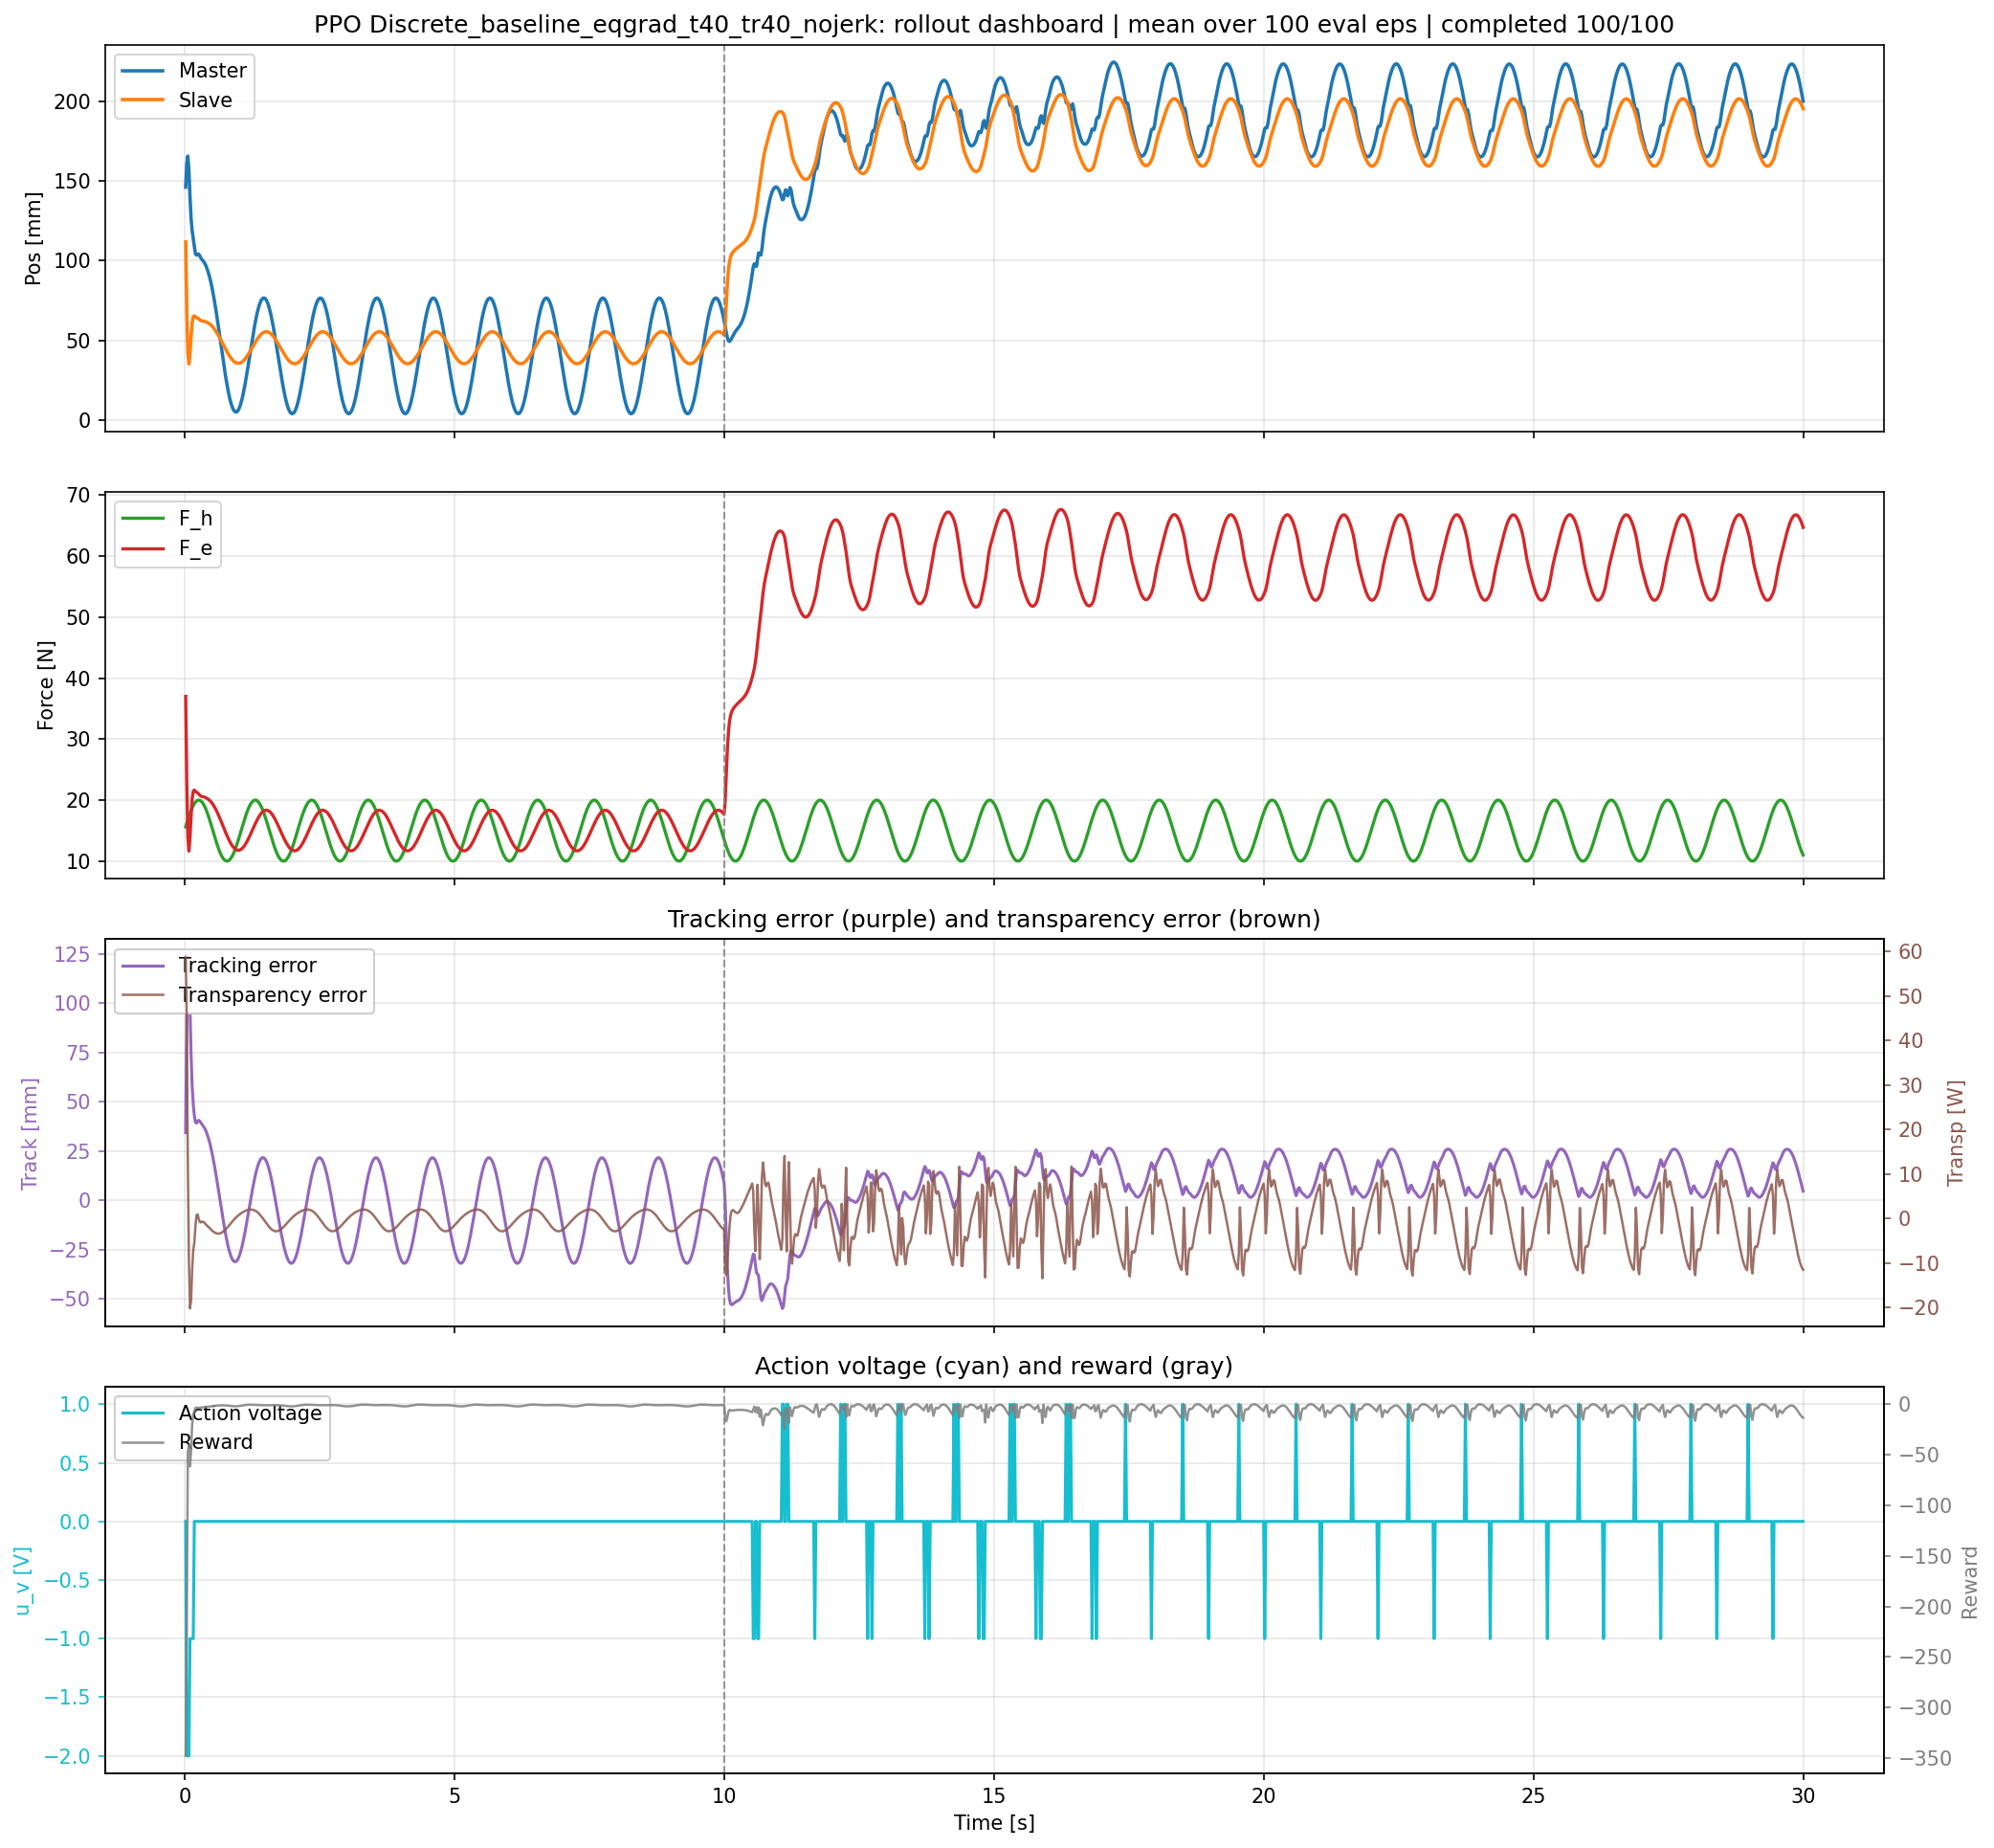

### gui_skin_locked: Evaluation action plot

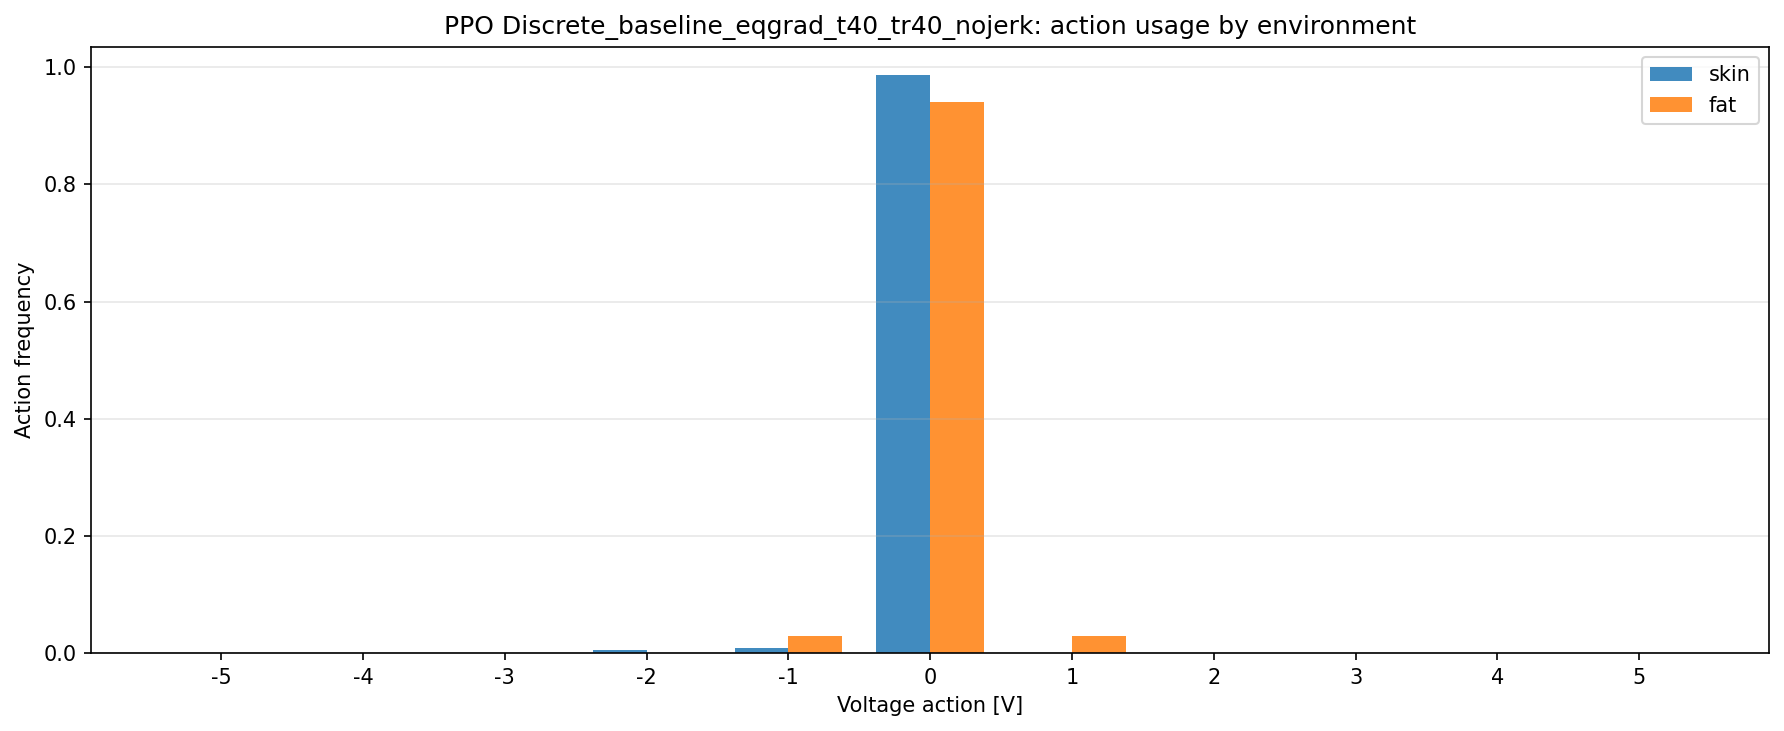

### gui_skin_locked: Evaluation trajectory plot

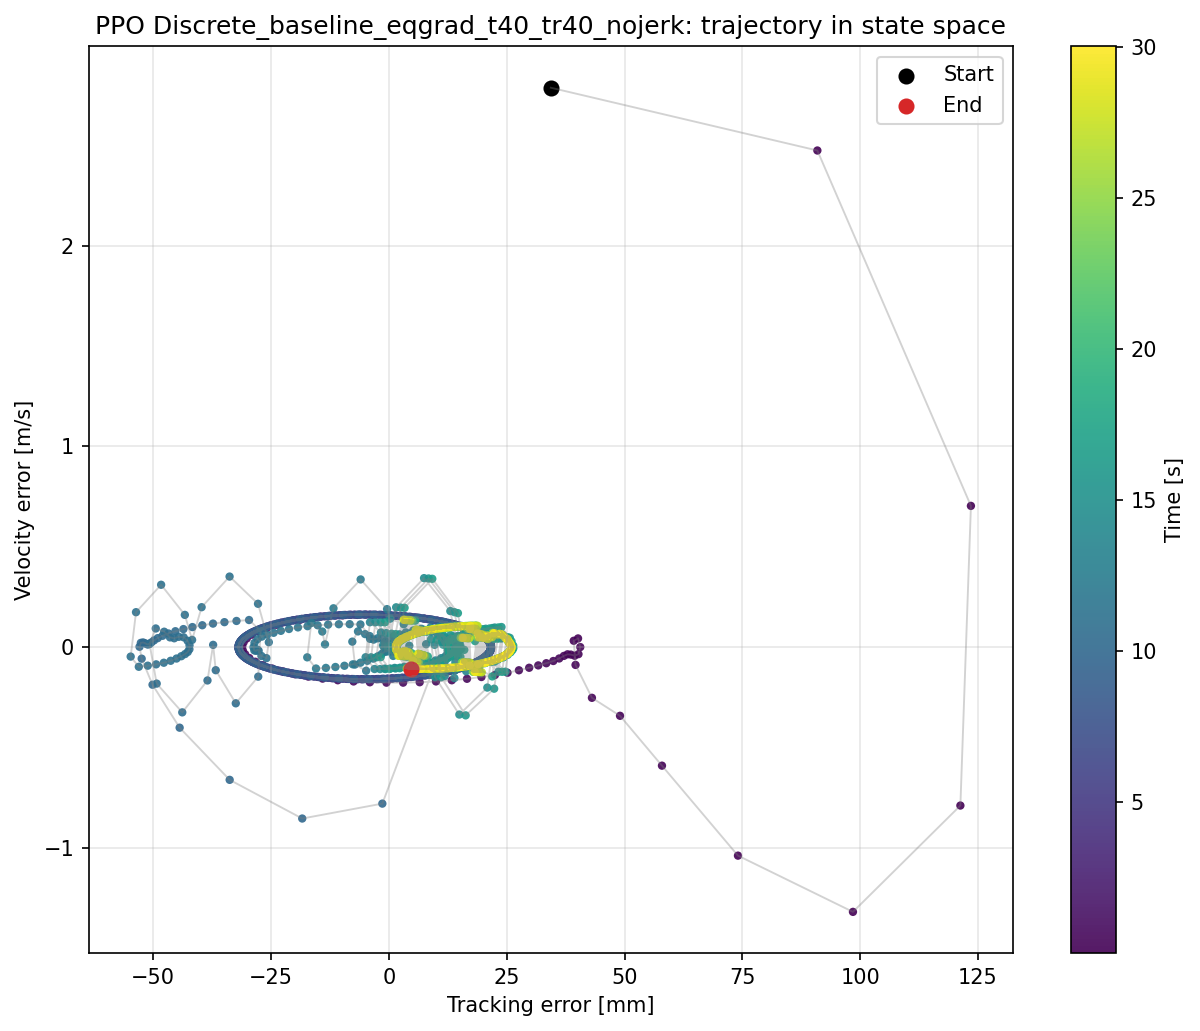

### gui_skin_locked: Policy slices

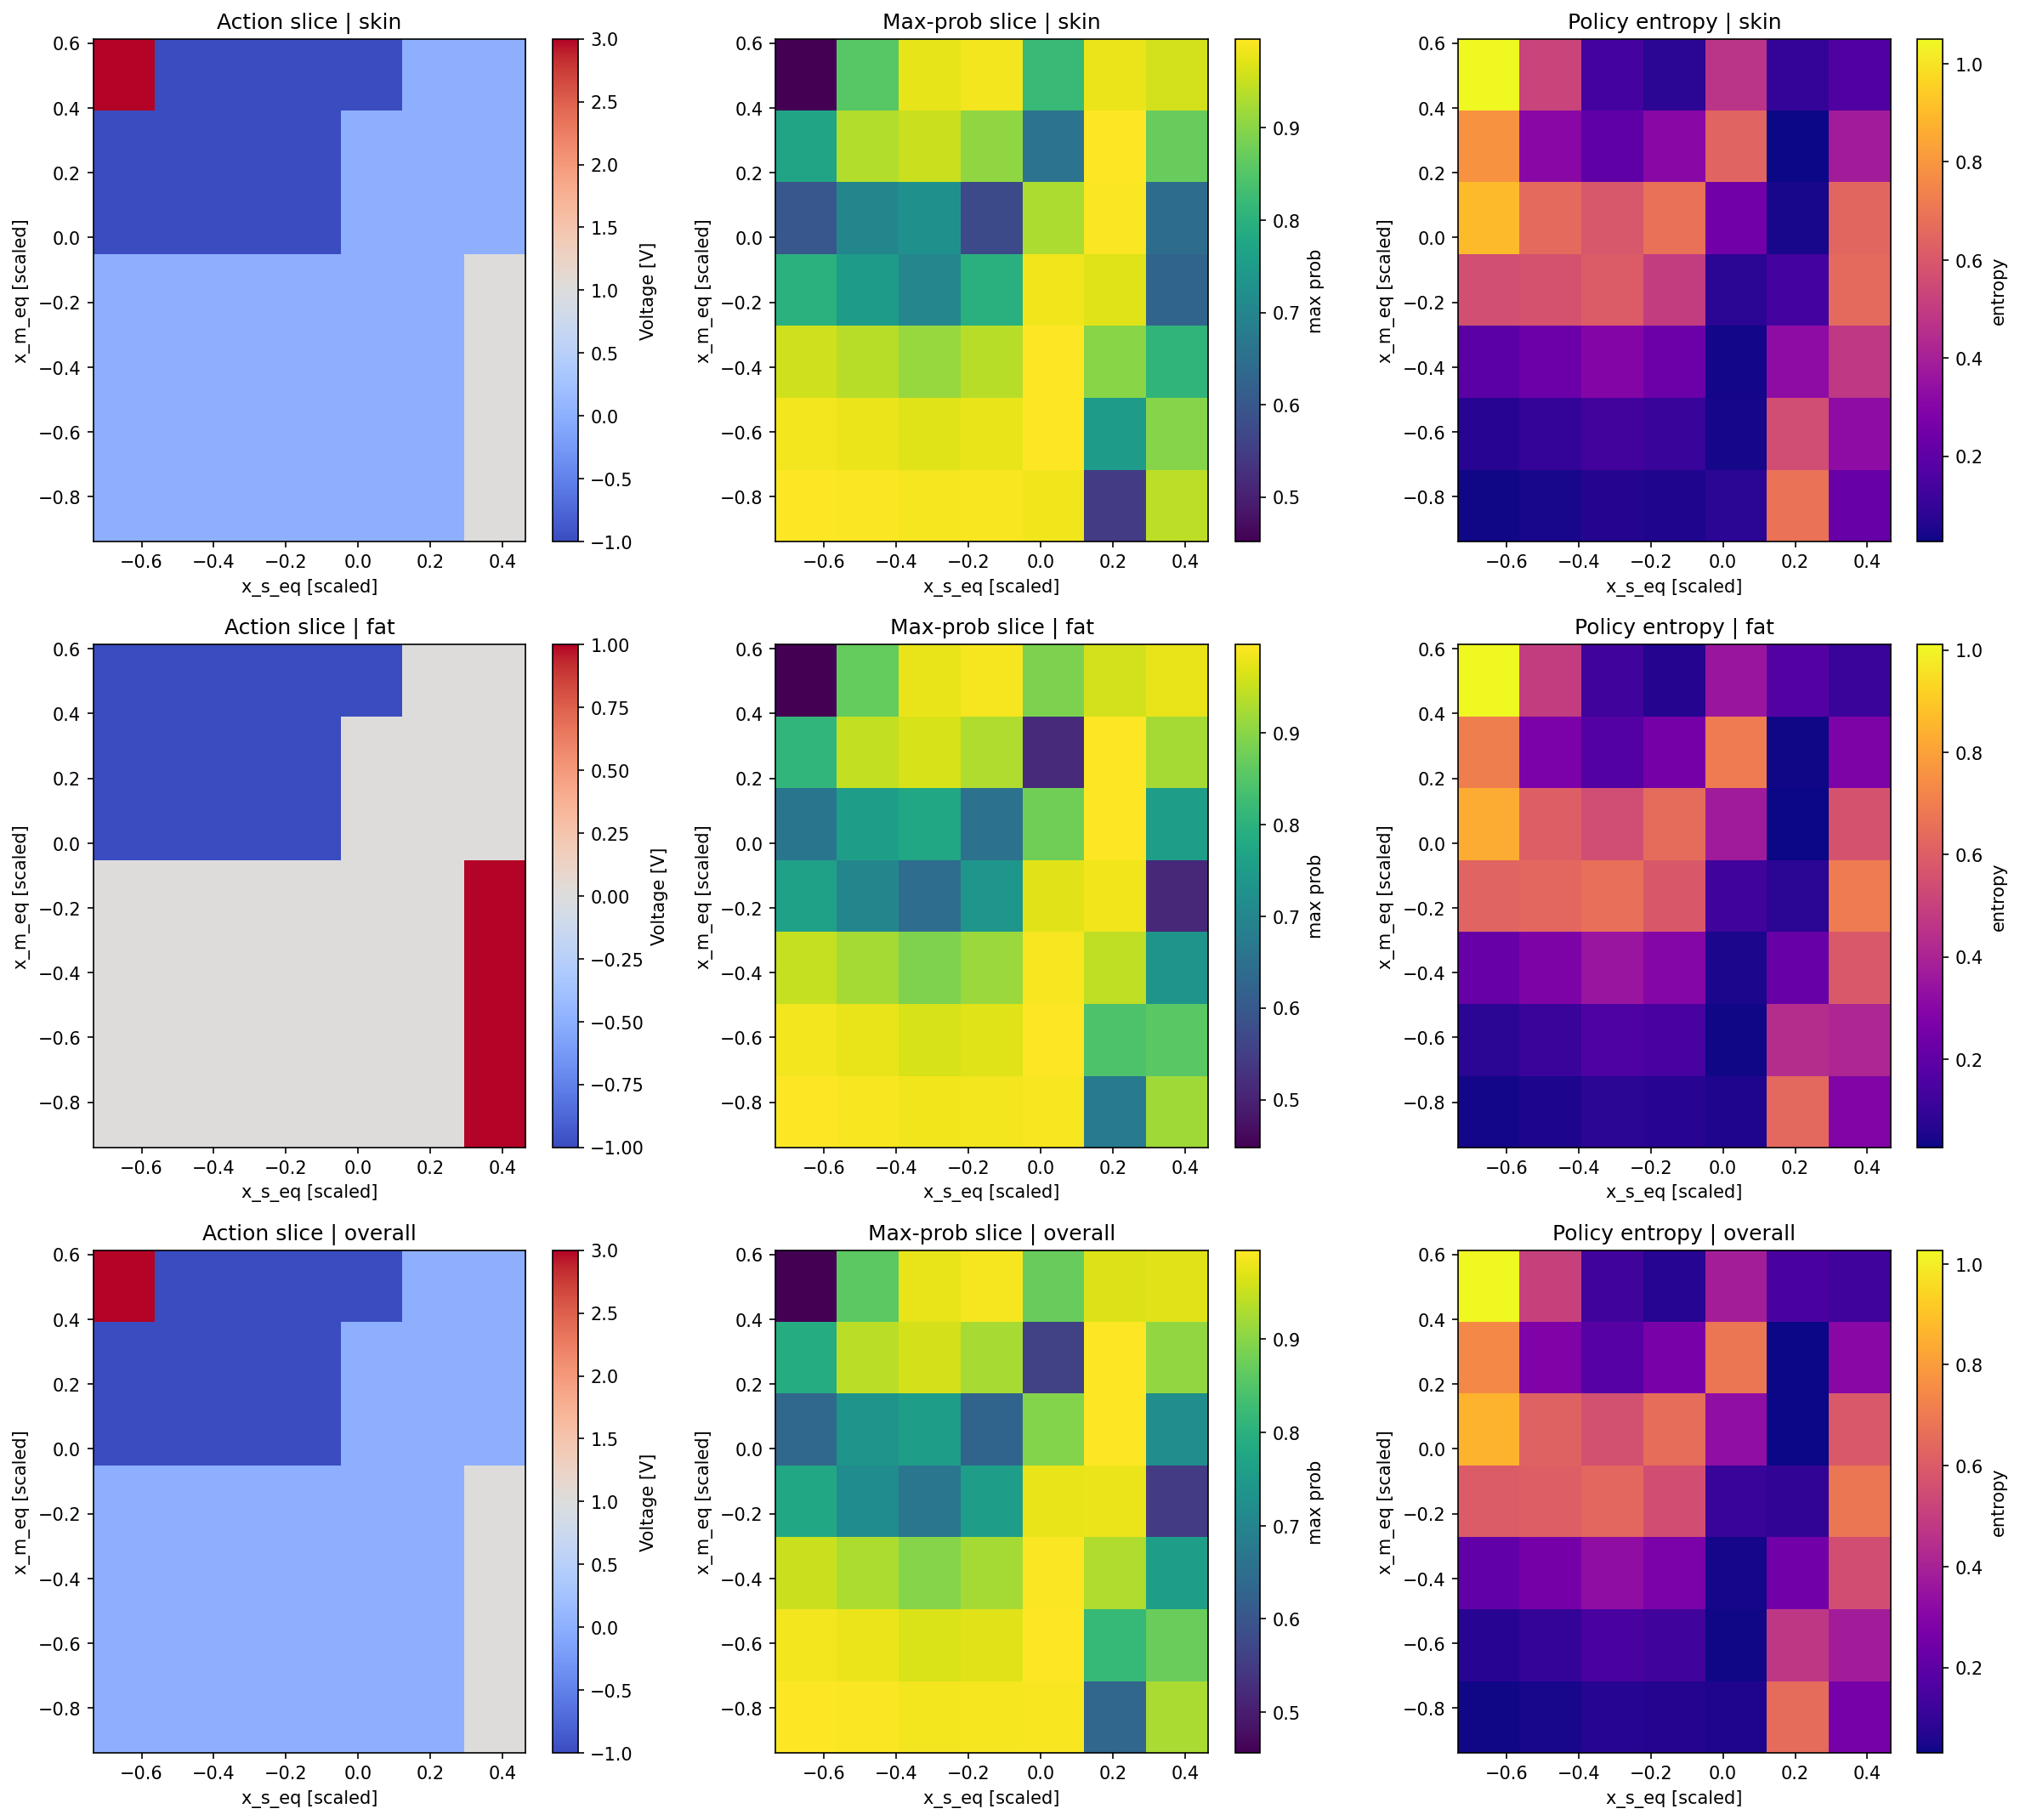

In [5]:
run_root = RUN_ROOTS['gui']
for filename, title in plot_specs:
    show_image(run_root / 'p' / filename, title=f"{MODE_LABELS['gui']}: {title}")
